In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle("cleaned_data.pkl")

### Customer Overview

Customers ages start at late teen and keep growing until around when people have children, when many parents focus more on child and family welfare than keeping up with the lastest fashion.

As the children hit 

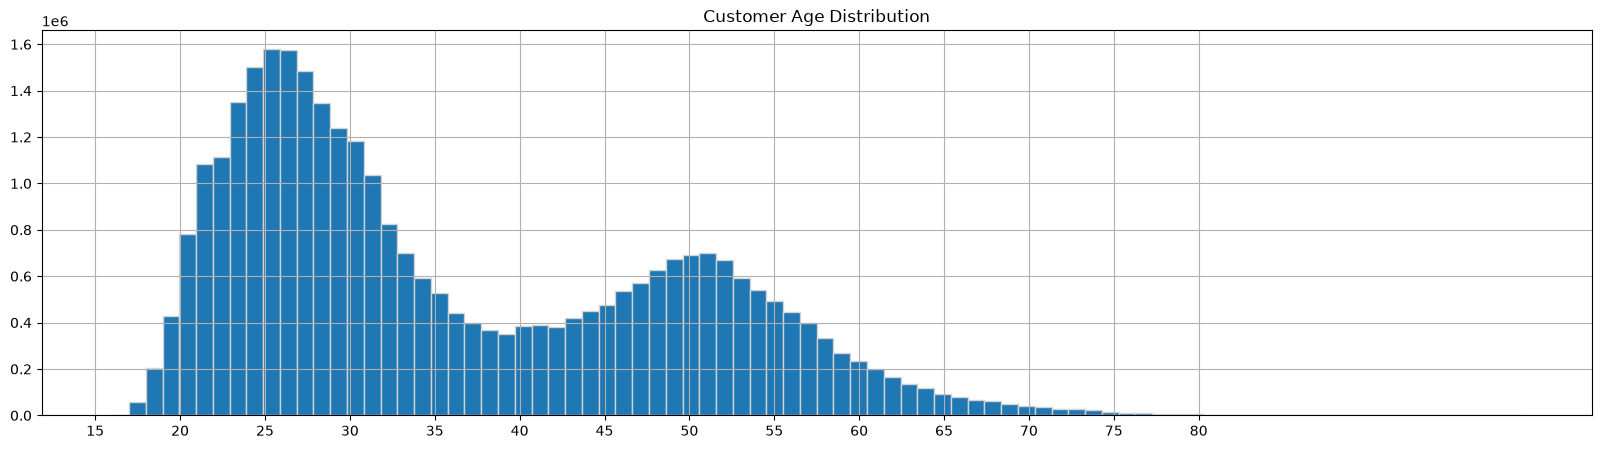

In [45]:
fig, ax = plt.subplots()

df['age'].hist(figsize=(20, 5), bins=84, edgecolor='lightgray')

ax.set_xticks(np.arange(15, 85, 5))

plt.title('Customer Age Distribution')

plt.show()

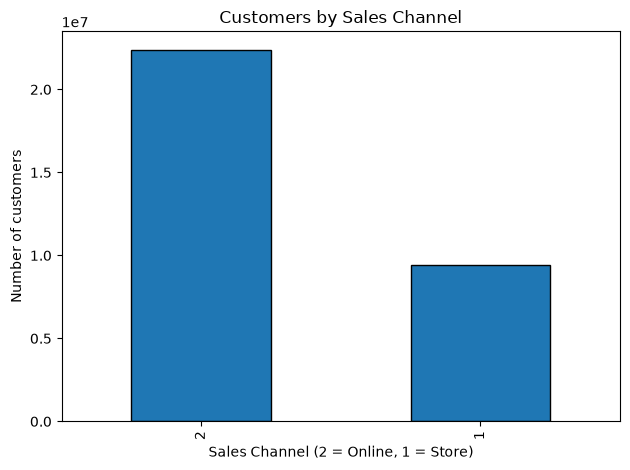

In [46]:
df['sales_channel_id'].value_counts().plot.bar( edgecolor='black')
plt.title('Customers by Sales Channel')
plt.xlabel('Sales Channel (2 = Online, 1 = Store)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

### Transaction Overview

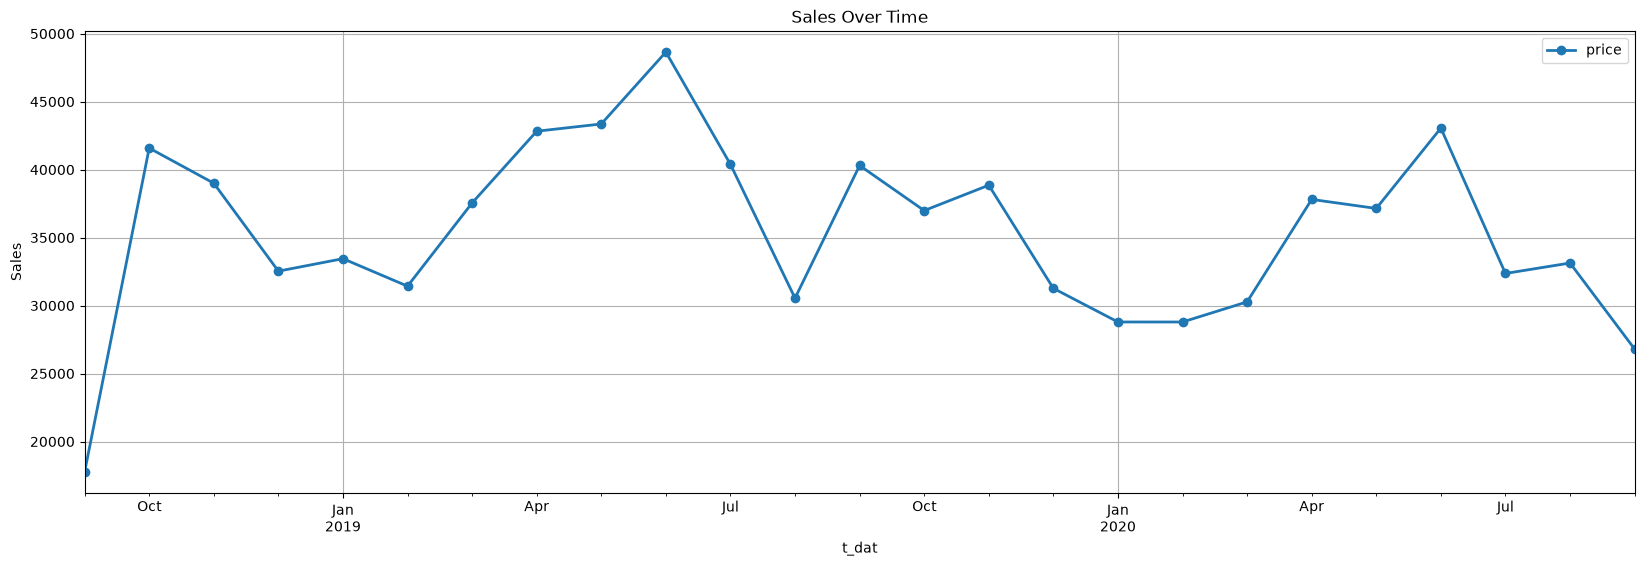

In [47]:
df['t_dat'] = pd.to_datetime(df['t_dat'])

monthly_sales = df.groupby(pd.Grouper(key='t_dat', freq='ME'))['price'].sum().reset_index()

monthly_sales = monthly_sales.set_index('t_dat')

monthly_sales.plot(kind='line', figsize=(20, 6), marker='o', linewidth=2)

plt.title('Sales Over Time')
plt.ylabel('Sales')
plt.grid(True)

plt.show()

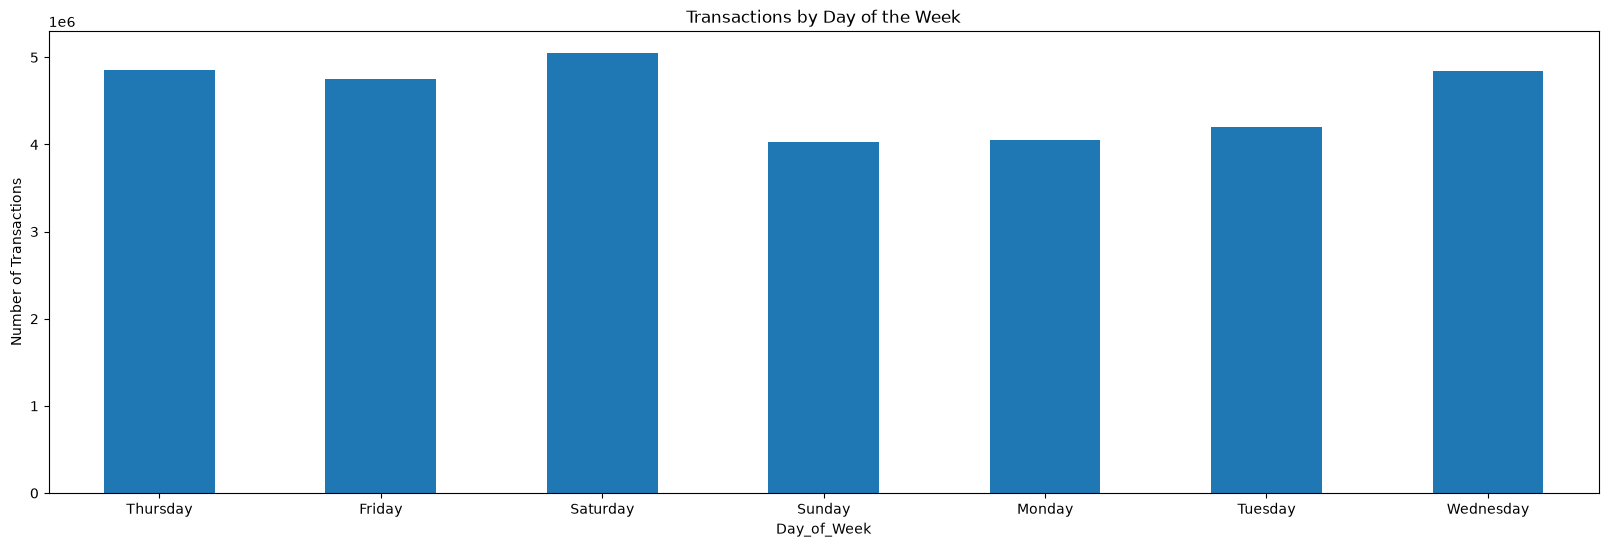

In [48]:

df['Day_of_Week'] = df['t_dat'].dt.day_name()

day_counts = df.groupby('Day_of_Week', sort=False)['t_dat'].count()

day_counts.plot(kind='bar', figsize=(20, 6))

plt.title('Transactions by Day of the Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

count    3.178832e+07
mean     2.782927e-02
std      1.918113e-02
min      1.694915e-05
25%      1.581356e-02
50%      2.540678e-02
75%      3.388136e-02
max      5.915254e-01
Name: price, dtype: float64


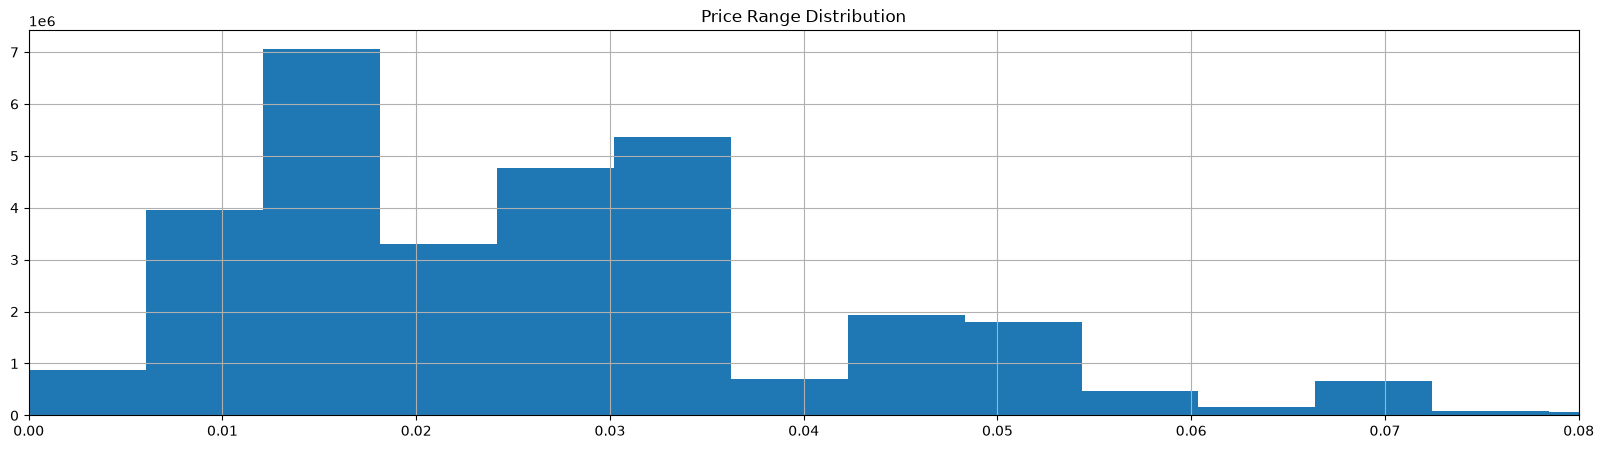

In [49]:
print(df['price'].describe())

#IQR (Q3 - Q1): 0.03388136 - 0.01581356 = 0.0180678
# Lower Bound (Q1 - 1.5 × IQR): -0.011288
# Upper Bound (Q3 + 1.5 × IQR): 0.0609832. 
# 
# There are no lower outliers. The absolute minimum value (0.0000169) sits well above the negative lower bound.
# 
# It is heavily skewed upward. The maximum value of 0.5915254 is nearly 10 times higher than the upper threshold limit (0.060983).
# 
# Furthermore, the 75th percentile is only 0.0338, which means at least 75% of the 31.7-million-row dataset is packed below that number. 
# 
# The jump from 0.0338 to a maximum of 0.5915 signals a long, sparse right-hand tail pulling the mean higher than your 50% median.

fig, ax = plt.subplots()

df['price'].hist(figsize=(20,5), bins=98)

# ax.set_xticks(np.arange(15, 85, 5))

plt.title('Price Range Distribution')
plt.xlim(0, 0.08) # exclude the extreme outliers to better visualize the distribution of the majority of the data
plt.show()

sales_channel_id
2    75.619306
1    24.380694
Name: price, dtype: float64


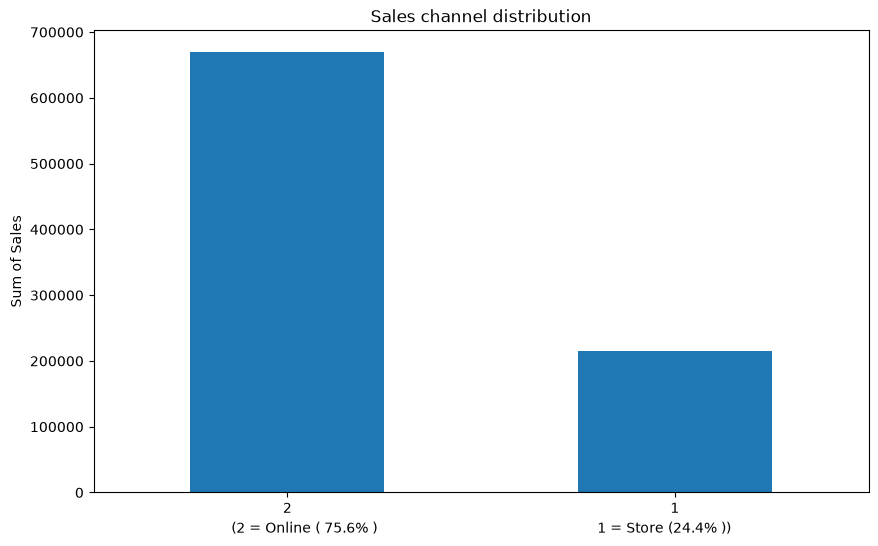

In [59]:
channel_sales = df.groupby('sales_channel_id', sort=False)['price'].sum()

print((channel_sales / df['price'].sum()) * 100)

sum_of_sales = df.groupby('sales_channel_id', sort=False)['price'].sum()

sum_of_sales.plot(kind='bar', figsize=(10, 6))

plt.title('Sales channel distribution')
plt.ylabel('Sum of Sales')
plt.xlabel('(2 = Online ( 75.6% )                                                       1 = Store (24.4% ))')
plt.xticks(rotation=0)
plt.show()


### Product Overview

In [51]:
# df.to_pickle('explored_data.pkl')